In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/digit-recognizer/sample_submission.csv
/kaggle/input/competitions/digit-recognizer/train.csv
/kaggle/input/competitions/digit-recognizer/test.csv


In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/kaggle/input/competitions/digit-recognizer/train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [5]:
df.shape

(42000, 785)

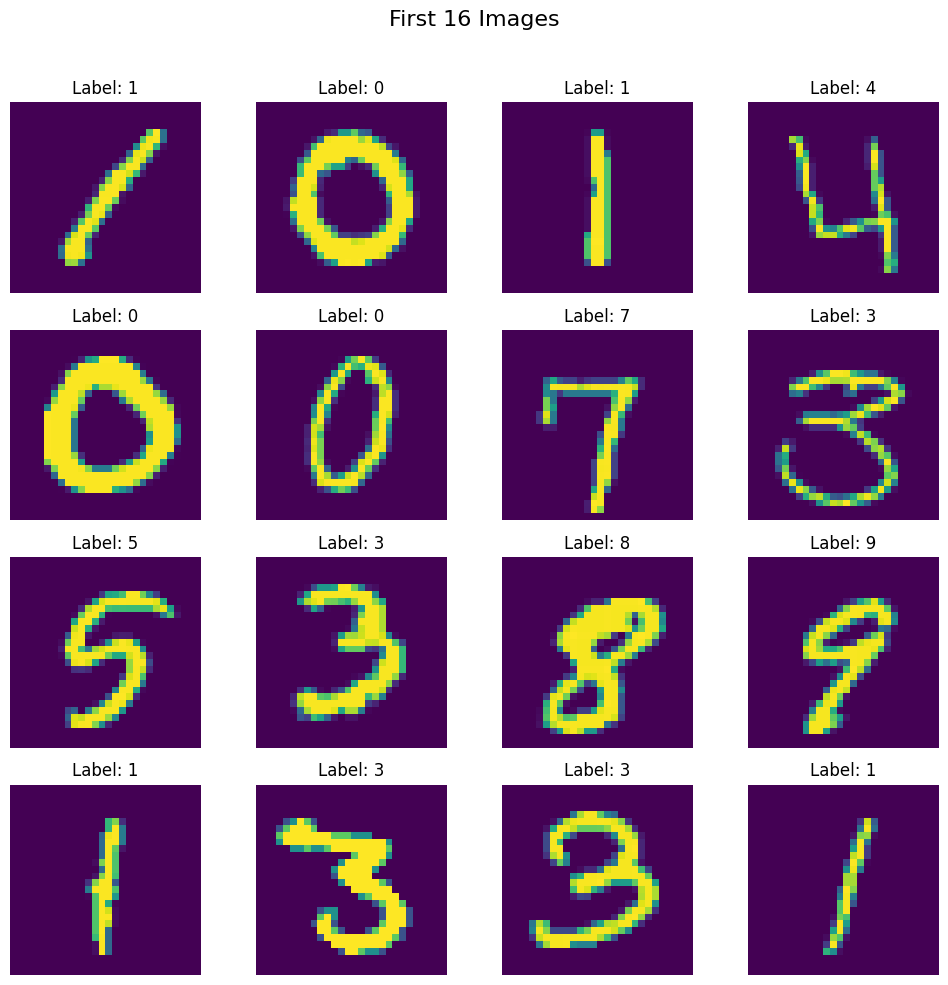

In [25]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [7]:
df = df.dropna() # Drop rows with NaN values
X_train = df.iloc[:, 1:].values
y_train = df.iloc[:, 0].values

In [8]:
X_train = X_train.reshape(-1, 1, 28, 28).astype(np.float32)
X_train = X_train/255.0

In [9]:
dft = pd.read_csv('/kaggle/input/competitions/digit-recognizer/test.csv')
dft.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [10]:
dft.shape

(28000, 784)

In [11]:
dft = dft.to_numpy(dtype=np.float32)
dft = dft / 255.0

In [12]:

X_test = df.iloc[:, 1:].values
y_test = df.iloc[:, 0].values

In [13]:
X_test.shape

(42000, 784)

In [14]:
X_test = X_train.reshape(-1, 1, 28, 28).astype(np.float32)
X_test = X_test/255.0

In [15]:
X_train.shape

(42000, 1, 28, 28)

In [16]:
from torch.utils.data import Dataset
import torch

class CustomDataset(Dataset):
    def __init__(self, images, labels=None):
        self.images = images
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = self.images[idx]

        # Convert to tensor if needed
        if not torch.is_tensor(image):
            image = torch.tensor(image, dtype=torch.float32)

        # Ensure shape is (1, 28, 28)
        image = image.reshape(1, 28, 28)

        if self.labels is None:
            return image

        label = self.labels[idx]
        if not torch.is_tensor(label):
            label = torch.tensor(label, dtype=torch.long)

        return image, label

In [17]:
# create train dataset
train_dataset = CustomDataset(X_train, y_train)
test_dataset = CustomDataset(dft)


In [18]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [19]:
class MyNN(nn.Module):
  def __init__(self, input_features):
    super().__init__()

    self.feautures = nn.Sequential(
        # 1x28x28
        nn.Conv2d(input_features, 32, kernel_size=3, padding='same'),
        nn.BatchNorm2d(32),
        nn.ReLU(),

        # 32x28x28
        nn.MaxPool2d(kernel_size=2, stride=2),
        
        # 32x14x14
        nn.Conv2d(32, 64, kernel_size=3, padding='same'),
        nn.BatchNorm2d(64),
        nn.ReLU(),

        # 64x14x14
        nn.MaxPool2d(kernel_size=2, stride=2),

        
        # 64x7x7
        nn.Conv2d(64, 128, kernel_size=3, padding='same'),
        nn.BatchNorm2d(128),
        nn.ReLU(),
    )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        
        nn.Linear(128*7*7, 256),
        nn.ReLU(),
        nn.Dropout(p=0.5),
        
        nn.Linear(256, 128),
        nn.ReLU(),
        nn.Dropout(p=0.5),

        nn.Linear(128, 10)
    )


  def forward(self,x):
    x = self.feautures(x)
    x = self.classifier(x)
    return x

In [20]:
learning_rate=0.01
epochs=15

In [21]:
model = MyNN(1)


# loss function
criterion = nn.CrossEntropyLoss()
#optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate, weight_decay=1e-4)

In [23]:
# training loop
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:
    # forward pass
    outputs = model(batch_features)



    # calculate loss
    loss = criterion(outputs, batch_labels)


    # backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_epoch_loss = total_epoch_loss + loss.item()

  avg_epoch_loss = total_epoch_loss/len(train_loader)
  print(f"Epoch {epoch+1}, Loss: {avg_epoch_loss}")

Epoch 1, Loss: 0.05961169924350102
Epoch 2, Loss: 0.051507892474827906
Epoch 3, Loss: 0.04178856935203842
Epoch 4, Loss: 0.03812775661962629
Epoch 5, Loss: 0.031976921813658625
Epoch 6, Loss: 0.029648490191636973
Epoch 7, Loss: 0.02473239032473179
Epoch 8, Loss: 0.025703852239419706
Epoch 9, Loss: 0.020828186479301673
Epoch 10, Loss: 0.020510843695727973
Epoch 11, Loss: 0.016979394796029015
Epoch 12, Loss: 0.015672376693706743
Epoch 13, Loss: 0.014868772140276204
Epoch 14, Loss: 0.011558274976693686
Epoch 15, Loss: 0.011824620485215171


In [26]:
model.eval()

MyNN(
  (feautures): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=same)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=6272, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): 

In [28]:
total = 0
correct = 0
with torch.no_grad():
  for batch_features, batch_labels in train_loader:
    outputs = model(batch_features)
    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item()

  accuracy = correct/total
print(f"Training Accuracy = {accuracy*100}")

Training Accuracy = 99.9452380952381


In [29]:
X_test.shape

(42000, 1, 28, 28)

In [30]:
model.eval()

predictions = []

with torch.no_grad():
    for images in test_loader:
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        predictions.extend(predicted.cpu().numpy())

In [31]:
len(predictions)

28000

In [163]:
submission = pd.DataFrame({
    "ImageId": np.arange(1, len(predictions) + 1),
    "Label": predictions
})

submission.to_csv("submission.csv", index=False)

In [32]:
torch.save(model, "digit_model.pt")